In [ ]:
"""
Exercise 4: NumPy Array Operations
"""
import numpy as np

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
matrix = np.zeros((5, 5))

matrix[0, :] = 1
matrix[4, :] = 1
matrix[:, 0] = 1
matrix[:, 4] = 1

print(matrix)

# Task 2: Normalize a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)

mean = random_data.mean(axis=0)
std = random_data.std(axis=0)

normalized_data = (random_data - mean) / std

print(normalized_data.mean(axis=0))
print(normalized_data.std(axis=0))

# Task 3: Calculate theta_hat using the normal equation and print the estimated coefficients and compare with true_theta
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

transpose_X = X.T
a = transpose_X @ X
b = transpose_X @ y
theta_hat = np.linalg.inv(a) @ b

print("Estimated coefficients:", theta_hat)
print("True theta:", true_theta)
print("Difference between estimated and true theta:", theta_hat - true_theta)


Estimated coefficients: [ 2.51723721 -1.19783796  3.72399266]
True theta: [ 2.5 -1.2  3.7]
Difference between estimated and true theta: [0.01723721 0.00216204 0.02399266]


In [ ]:
"""
Exercise 5: Pandas Data Analysis
"""
import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200

data = {
    "student_id": range(1000, 1000 + n_students),
    "major": np.random.choice(["CS", "Math", "Physics", "Biology"], n_students),
    "year": np.random.choice([1, 2, 3, 4], n_students),
    "exam_score": np.random.normal(75, 10, n_students).clip(0, 100),
    "assignments_completed": np.random.randint(0, 11, n_students),
    "hours_studied": np.random.normal(15, 5, n_students).clip(1, 40),
}

df = pd.DataFrame(data)


df.loc[np.random.choice(n_students, 10), "exam_score"] = np.nan
df.loc[np.random.choice(n_students, 5), "hours_studied"] = np.nan

# Task 1: Data Cleaning and Exploration
print("Dataset Info:")
print(df.info())

print("First 5 Rows:")
print(df.head())

print("Statistical Summary:")
print(df.describe())

# Identify and count missing values
missing_values_count = df.isnull().sum()


# Fill missing exam_score with the mean score for the student's major
df["exam_score"] = df.groupby("major")["exam_score"].transform(
    lambda x: x.fillna(x.mean())
)

# Fill missing hours_studied with the median for the student's year
df["hours_studied"] = df.groupby("year")["hours_studied"].transform(
    lambda x: x.fillna(x.median())
)

# Task 2: Analysis
# Calculate and display the average exam_score by major
avg_scores = df.groupby("major")["exam_score"].mean()

print("Average Exam Score by Major:")
print(avg_scores)

# Find the major with the highest average exam_score
top_major = avg_scores.idxmax()

# Calculate the correlation between hours_studied and exam_score
correlation = df["hours_studied"].corr(df["exam_score"])

# Create a new column 'performance' with categories:
#  'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
conditions = [
    df["exam_score"] > 90,
    (df["exam_score"] >= 80) & (df["exam_score"] <= 90),
    (df["exam_score"] >= 70) & (df["exam_score"] < 80),
]

choices = ["Excellent", "Good", "Average"]

df["performance"] = np.select(conditions, choices, default="Needs Improvement")

# Task 3: Advanced Analysis
# For each major and year combination, calculate:
#  -Number of students
#  -Average exam score
#  -Average hours studied
group_analysis = df.groupby(["major", "year"]).agg(
    {"student_id": "count", "exam_score": "mean", "hours_studied": "mean"}
)

# Identify top 5 students based on exam_score (handle ties appropriately)
top_students = df.nlargest(5, "exam_score")

# Create a pivot table showing average exam_score by major (rows) and year (columns)
pivot_table = df.pivot_table(
    values="exam_score", index="major", columns="year", aggfunc="mean"
)


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None
First 5 Rows:
   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                      2      14.04

In [ ]:
"""
Exercise 6: Data Visualization
"""
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Distribution Visualization
# Create a figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of exam scores with KDE overlay
sns.histplot(data=df, x="exam_score", kde=True, ax=axes[0])

axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Frequency")

# Box plot of exam scores by major
sns.boxplot(data=df, x="major", y="exam_score", ax=axes[1])

axes[1].set_title("Exam Scores by Major")
axes[1].set_xlabel("Major")
axes[1].set_ylabel("Exam Score")

# Task 2: Relationship Visualization
plt.figure(figsize=(10, 6))

# Create a scatter plot of hours_studied vs exam_score
sns.scatterplot(data=df, x="hours_studied", y="exam_score", hue="major")

# Add a regression line
sns.regplot(data=df, x="hours_studied", y="exam_score", scatter=False, color="black")

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

# Task 3: Advanced Dashboard
# Bar chart: Average exam score by major
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

avg_scores = df.groupby("major")["exam_score"].mean()

axes[0, 0].bar(avg_scores.index, avg_scores.values)

axes[0, 0].set_title("Average Exam Score by Major")
axes[0, 0].set_xlabel("Major")
axes[0, 0].set_ylabel("Average Score")

# Count plot: Number of students by year
sns.countplot(data=df, x="year", ax=axes[0, 1])

axes[0, 1].set_title("Number of Students by Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Count")

# Heat map: Correlation matrix of numerical columns
correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", ax=axes[1, 0])

axes[1, 0].set_title("Correlation Matrix")

# Violin plot: Exam score distribution by performance category
sns.violinplot(data=df, x="performance", y="exam_score", ax=axes[1, 1])

axes[1, 1].set_title("Exam Score Distribution by Performance")

axes[1, 1].set_xlabel("Performance")
axes[1, 1].set_ylabel("Exam Score")


   purchase_frequency  avg_purchase_value  churn_risk          CLV
0                   7           94.527456    0.416667   937.397271
1                   2          100.932279    0.833333   370.085023
2                   3           79.699876    0.750000   418.424348
3                   2          130.137787    0.833333   477.171887
4                   8          102.904845    0.333333  1097.651683
   age age_group
0   56     51-70
1   69     51-70
2   46     36-50
3   32     26-35
4   60     51-70
           num_customers    avg_income     avg_CLV      total_CLV
age_group                                                        
18-25                 81  50634.018330  718.371170   58188.064760
26-35                 73  48747.148046  747.738562   54584.915035
36-50                160  48516.895668  732.796612  117247.457917
51-70                186  50713.163384  762.693498  141860.990683
Top 10% customers:
     age        income          CLV
426   42  68713.567863  1645.711441
213   41 

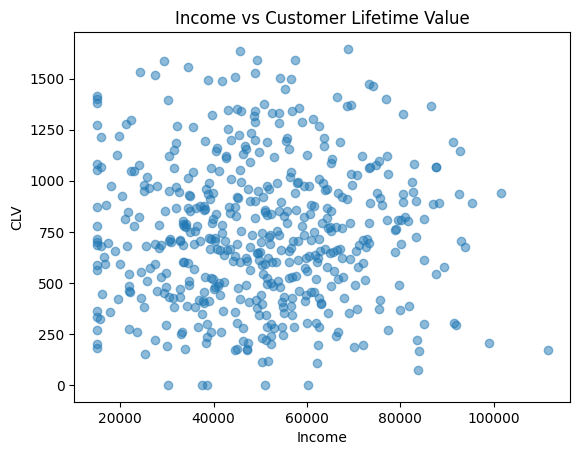

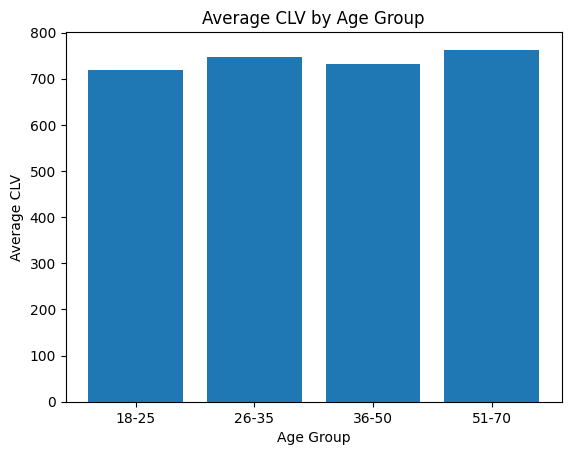

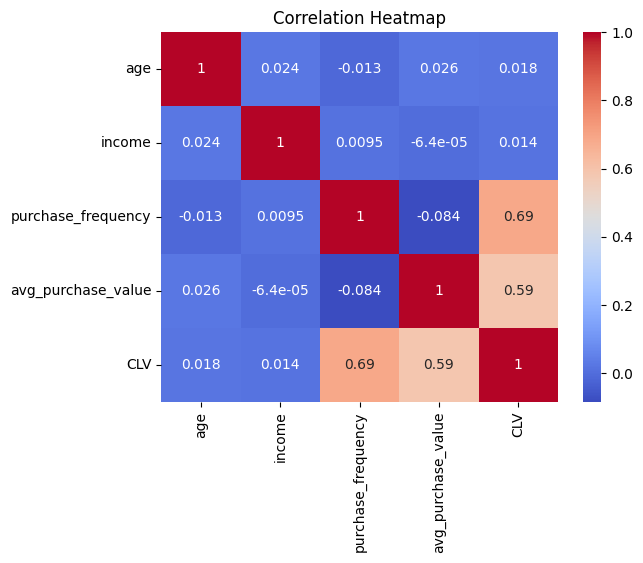

In [3]:
"""Exercise 7: Integration Challenge"""
# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame(
    {
        "age": ages,
        "income": income,
        "purchase_frequency": purchase_freq,
        "avg_purchase_value": avg_purchase_value,
    }
)

# Calculate customer lifetime value (CLV)
#   CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#   where churn_risk = 1 - (purchase_frequency / max_frequency)
max_freq = customers["purchase_frequency"].max()
customers["churn_risk"] = 1 - (customers["purchase_frequency"] / max_freq)

customers["CLV"] = (
    customers["purchase_frequency"]
    * customers["avg_purchase_value"]
    * (1 + customers["churn_risk"])
)

print(
    customers[["purchase_frequency", "avg_purchase_value", "churn_risk", "CLV"]].head()
)

# Create age groups: 18-25, 26-35, 36-50, 51-70
bins = [18, 25, 35, 50, 70]
labels = ["18-25", "26-35", "36-50", "51-70"]

customers["age_group"] = pd.cut(
    customers["age"], bins=bins, labels=labels, include_lowest=True
)

print(customers[["age", "age_group"]].head())

# For each age group, calculate:
#   - Number of customers
#   - Average income
#   - Average CLV
#   - Total CLV

group_stats = customers.groupby("age_group").agg(
    num_customers=("age", "count"),
    avg_income=("income", "mean"),
    avg_CLV=("CLV", "mean"),
    total_CLV=("CLV", "sum"),
)

print(group_stats)


# Identify top 10% of customers by CLV
threshold = customers["CLV"].quantile(0.9)

top_customers = customers[customers["CLV"] >= threshold]

print("Top 10% customers:")
print(top_customers[["age", "income", "CLV"]].sort_values(by="CLV", ascending=False))

# Create visualizations:
#    1. Scatter plot of income vs CLV (color by age group)
plt.figure()

plt.scatter(customers["income"], customers["CLV"], alpha=0.5)

plt.xlabel("Income")
plt.ylabel("CLV")
plt.title("Income vs Customer Lifetime Value")

plt.show()

#    2. Bar chart of average CLV by age group
avg_clv_by_age = customers.groupby("age_group")["CLV"].mean()

plt.figure()

plt.bar(avg_clv_by_age.index.astype(str), avg_clv_by_age.values)

plt.xlabel("Age Group")
plt.ylabel("Average CLV")
plt.title("Average CLV by Age Group")

plt.show()

#    3. Correlation heatmap
plt.figure()

corr = customers[
    ["age", "income", "purchase_frequency", "avg_purchase_value", "CLV"]
].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()


#Write a brief analysis paragraph (as a markdown cell) summarizing key findings and recommendations

The results show that the Customer Lifetime Value is primarily influenced by how often customers buy and how much they spend on average. Customers who purchase more frequently and have higher spending values often have a much higher CLV, regardless of whether their income is high.
Additionally, the results show that customers aged 51-70 years old have the highest higher total CLV. This however, is likely influenced by that age group making up a large portion of the dataset.
The age group 26-35 have the lowest total CLV. This suggests that they purchase less frequently that the other age group however, it is important to note that they make up the smallest portion of this dataset
